# Datathon Passos Mágicos — Notebook 01: Leitura e Limpeza

**Fonte:** PEDE 2022, 2023 e 2024 (arquivos Excel)  
**Saída:** `data/pede_consolidado.csv` — dataset limpo e unificado

### Mapeamento de colunas (PEDE 2022 como referência)
| Coluna no Excel | Significado |
|---|---|
| `RA` | Identificador único do aluno |
| `Fase` | Nível de aprendizado (1–8) |
| `Pedra 22 / 21 / 20` | Classificação: Quartzo / Ágata / Ametista / Topázio |
| `INDE 22` | Índice de Desenvolvimento Educacional |
| `IAA` | Indicador de Autoavaliação |
| `IEG` | Indicador de Engajamento |
| `IPS` | Indicador Psicossocial |
| `IDA` | Indicador de Aprendizagem |
| `IPP` | Indicador Psicopedagógico |
| `IPV` | Indicador de Ponto de Virada |
| `IAN` | Indicador de Adequação ao Nível |
| `Defas` | Defasagem (0=adequado, positivo=defasado, negativo=adiantado) |
| `Atingiu PV` | Ponto de Virada (Sim/Não) |

## 0. Imports e configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

DATA_PATH = 'C:\\Users\\thiag\\Desktop\\POSTECH 5\\passos_magicos\\data\\'

ARQUIVOS = {
    2022: 'BASE DE DADOS PEDE 2024 - DATATHON - PEDE2022.csv',
    2023: 'BASE DE DADOS PEDE 2024 - DATATHON - PEDE2023.csv',
    2024: 'BASE DE DADOS PEDE 2024 - DATATHON - PEDE2024.csv',
}

print('Configuracoes carregadas')

Configuracoes carregadas


## 1. Carregamento dos arquivos Excel

In [2]:
dfs_raw = {}

for ano, arquivo in ARQUIVOS.items():
    caminho = os.path.join(DATA_PATH, arquivo)
    try:
        df = pd.read_csv(caminho, encoding='utf-8', sep=',')
        dfs_raw[ano] = df
        print(f'{ano}: {df.shape[0]} alunos x {df.shape[1]} colunas')
    except Exception as e:
        # Tenta latin-1 se utf-8 falhar
        try:
            df = pd.read_csv(caminho, encoding='latin-1', sep=',')
            dfs_raw[ano] = df
            print(f'{ano}: {df.shape[0]} alunos x {df.shape[1]} colunas (latin-1)')
        except Exception as e2:
            print(f'ERRO {ano}: {e2}')

2022: 860 alunos x 42 colunas
2023: 1014 alunos x 48 colunas
2024: 1156 alunos x 50 colunas


In [3]:
# Inspecionar colunas de cada ano
for ano, df in dfs_raw.items():
    print(f'\n--- PEDE {ano} ({df.shape[0]} registros) ---')
    print(df.columns.tolist())


--- PEDE 2022 (860 registros) ---
['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']

--- PEDE 2023 (1014 registros) ---
['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado', 'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fas

In [4]:
for ano, df in dfs_raw.items():
    print(f'\n--- PEDE {ano} --- primeiras 2 linhas')
    display(df.head(2))


--- PEDE 2022 --- primeiras 2 linhas


,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,INDE 22,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,Rec Psicologia,IDA,Matem,Portug,Inglês,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,Ametista,Quartzo,"5,783","753,000",18,10,4,Avaliador-5,Mantido na Fase atual,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Mantido na Fase atual,"8,3","4,1","5,6",Requer avaliação,"4,0","2,7","3,5","6,0",Sim,Não,"7,278","5,000",Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,Ametista,Ametista,"7,055","469,000",8,3,4,Avaliador-5,Promovido de Fase,Avaliador-27,Promovido de Fase + Bolsa,Avaliador-28,Promovido de Fase,Avaliador-31,Promovido de Fase + Bolsa,"8,8","5,2","6,3",Sem limitações,"6,8","6,3","4,5","9,7",Não,Não,"6,778","10,000",Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...



--- PEDE 2023 --- primeiras 2 linhas


,RA,Fase,INDE 2023,Pedra 2023,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,Pedra 23,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Rec Av3,Avaliador4,Rec Av4,IAA,IEG,IPS,IPP,Rec Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1
0,RA-861,ALFA,"9,31095",Topázio,ALFA A - G0/G1,Aluno-861,6/17/2015,8,Feminino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,"9,5","10,0","8,13","8,4375",NaN,"9,6","9,8","9,4",NaN,NaN,NaN,"8,92",10,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
1,RA-862,ALFA,"8,2212",Topázio,ALFA A - G0/G1,Aluno-862,5/31/2014,9,Masculino,2023,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,Avaliador-11,NaN,Avaliador-2,NaN,NaN,NaN,NaN,NaN,"8,5","9,1","8,14","7,5",NaN,"8,9","8,5","9,2",NaN,NaN,NaN,"8,585",5,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,NaN



--- PEDE 2024 --- primeiras 2 linhas


,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,Pedra 23,INDE 22,INDE 23,Cg,Cf,Ct,Nº Av,Avaliador1,Rec Av1,Avaliador2,Rec Av2,Avaliador3,Avaliador4,Avaliador5,Avaliador6,IAA,IEG,IPS,IPP,Rec Psicologia,IDA,Mat,Por,Ing,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1275,ALFA,"7,611366667",Ametista,ALFA A - G0/G1,Aluno-1275,28/07/2016,8,Masculino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,"10,0","8,7","6,3","5,6",NaN,"8,0","10,0","6,0",NaN,NaN,NaN,"5,4",10,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
1,RA-1276,ALFA,"8,002866667",Topázio,ALFA A - G0/G1,Aluno-1276,16/10/2016,8,Feminino,2024,Pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Avaliador-11,NaN,Avaliador-2,NaN,Avaliador-9,NaN,NaN,NaN,"10,0","9,3","3,8","7,5",NaN,"8,0","10,0","6,0",NaN,NaN,NaN,"7,1",10,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando


## 2. Funcoes auxiliares de limpeza

In [5]:
def converter_decimal_br(serie):
    """
    Converte valores com virgula decimal para float.
    Exemplo: '5,783' -> 5.783
    Cuida tambem de valores com ponto como separador de milhar.
    """
    if serie.dtype == object:
        return (
            serie.astype(str)
            .str.strip()
            .str.replace(',', '.', regex=False)
            .pipe(pd.to_numeric, errors='coerce')
        )
    return pd.to_numeric(serie, errors='coerce')


def detectar_coluna(df, candidatos):
    """Retorna o primeiro candidato encontrado nas colunas do df (case-insensitive)."""
    cols_lower = {c.lower().strip(): c for c in df.columns}
    for c in candidatos:
        if c.lower() in cols_lower:
            return cols_lower[c.lower()]
    return None


print('Funcoes auxiliares definidas')

Funcoes auxiliares definidas


In [6]:
INDICADORES = ['INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN']

def extrair_numero_fase(valor):
    s = str(valor).strip().upper()
    if s in ('NAN', 'NONE', ''):
        return pd.NA
    if 'ALFA' in s:
        return 0
    if s.startswith('FASE'):
        partes = s.replace('FASE', '').strip()
        try:
            return int(partes)
        except:
            return pd.NA
    import re
    m = re.match(r'^(\d+)', s)
    if m:
        return int(m.group(1))
    try:
        return int(s)
    except:
        return pd.NA


def limpar_pede(df, ano):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df['ANO'] = ano

    # --- ID do aluno ---
    col_id = detectar_coluna(df, ['RA', 'ID_ALUNO', 'NOME', 'Aluno'])
    if col_id and col_id != 'RA':
        df = df.rename(columns={col_id: 'RA'})
    print(f'  [{ano}] ID do aluno: "{col_id}"')

    # --- Fase ---
    col_fase = detectar_coluna(df, ['Fase', 'FASE'])
    if col_fase:
        df['Fase'] = df[col_fase].apply(extrair_numero_fase).astype('Int64')
        print(f'  [{ano}] Fases: {sorted(df["Fase"].dropna().unique().tolist())}')

    # --- Pedra do ano atual ---
    sufixo_2 = str(ano)[-2:]
    sufixo_4 = str(ano)
    col_pedra = detectar_coluna(df, [
        f'Pedra {sufixo_4}',
        f'Pedra {sufixo_2}',
        'Pedra'
    ])
    if col_pedra is None or df[col_pedra].isna().all():
        cols_pedra = [c for c in df.columns if 'pedra' in c.lower()]
        for c in reversed(cols_pedra):
            if df[c].notna().sum() > 0:
                col_pedra = c
                break
    if col_pedra:
        if col_pedra != 'Pedra':
            df = df.rename(columns={col_pedra: 'Pedra'})
        LIXO = {'NAN', 'NONE', '', '#DIV/0!', 'INCLUIR', 'N/A', 'NA'}
        df['Pedra'] = (
            df['Pedra'].astype(str).str.strip().str.upper()
            .str.normalize('NFKD')
            .str.encode('ascii', errors='ignore')
            .str.decode('ascii')
            .apply(lambda x: np.nan if x in LIXO else x)
        )
        print(f'  [{ano}] Pedras: {df["Pedra"].value_counts().to_dict()}')

    # --- INDE ---
    col_inde = detectar_coluna(df, [
        f'INDE {sufixo_2}', f'INDE {sufixo_4}', f'INDE_{ano}', 'INDE'
    ])
    if col_inde:
        if col_inde != 'INDE':
            df = df.rename(columns={col_inde: 'INDE'})
        df['INDE'] = converter_decimal_br(df['INDE'])

    # --- Demais indicadores ---
    for ind in ['IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN']:
        col = detectar_coluna(df, [ind, f'{ind}_{ano}'])
        if col and col != ind:
            df = df.rename(columns={col: ind})
        if ind in df.columns:
            df[ind] = converter_decimal_br(df[ind])

    inds_presentes = [c for c in INDICADORES if c in df.columns]
    print(f'  [{ano}] Indicadores: {inds_presentes}')

    # --- Defasagem ---
    col_defas = detectar_coluna(df, ['Defas', 'Defasagem', 'DEFASAGEM'])
    if col_defas and col_defas != 'Defas':
        df = df.rename(columns={col_defas: 'Defas'})
    if 'Defas' in df.columns:
        df['Defas'] = pd.to_numeric(df['Defas'], errors='coerce').astype('Int64')

    # --- Ponto de Virada ---
    col_pv = detectar_coluna(df, ['Atingiu PV', 'PONTO_VIRADA', 'Atingiu_PV'])
    if col_pv:
        df['Atingiu_PV'] = (
            df[col_pv].astype(str).str.strip().str.upper()
            .map({'SIM': 1, 'NAO': 0, 'NÃO': 0, 'S': 1, 'N': 0, '1': 1, '0': 0})
        )
        if col_pv != 'Atingiu_PV':
            df = df.drop(columns=[col_pv], errors='ignore')

    # --- Genero ---
    col_gen = detectar_coluna(df, ['Gênero', 'Genero', 'GENERO'])
    if col_gen:
        df = df.rename(columns={col_gen: 'Genero'})
        df['Genero'] = df['Genero'].astype(str).str.strip()

    # --- Duplicatas ---
    n_antes = len(df)
    df = df.drop_duplicates(subset=['RA'])
    if n_antes > len(df):
        print(f'  [{ano}] {n_antes - len(df)} duplicatas removidas')

    print(f'  [{ano}] OK: {len(df)} registros finais')
    return df

print('Funcao limpar_pede corrigida!')

Funcao limpar_pede corrigida!


In [7]:
dfs_limpos = {}
for ano, df in dfs_raw.items():
    print(f'\nLimpando PEDE {ano}...')
    dfs_limpos[ano] = limpar_pede(df, ano)


Limpando PEDE 2022...
  [2022] ID do aluno: "RA"
  [2022] Fases: [0, 1, 2, 3, 4, 5, 6, 7]


  [2022] Pedras: {'AMETISTA': 348, 'AGATA': 250, 'QUARTZO': 132, 'TOPAZIO': 130}
  [2022] Indicadores: ['INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN']
  [2022] OK: 860 registros finais

Limpando PEDE 2023...
  [2023] ID do aluno: "RA"
  [2023] Fases: [0, 1, 2, 3, 4, 5, 6, 7, 8]
  [2023] Pedras: {'AMETISTA': 381, 'AGATA': 246, 'TOPAZIO': 232, 'QUARTZO': 72}
  [2023] Indicadores: ['INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN']
  [2023] OK: 1014 registros finais

Limpando PEDE 2024...
  [2024] ID do aluno: "RA"
  [2024] Fases: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  [2024] Pedras: {'AMETISTA': 391, 'TOPAZIO': 326, 'AGATA': 225, 'QUARTZO': 112}
  [2024] Indicadores: ['INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN']
  [2024] OK: 1156 registros finais


In [8]:
# Corrigir INDE do 2023 manualmente
dfs_limpos[2023]['INDE'] = converter_decimal_br(dfs_raw[2023]['INDE 2023'])

# Corrigir INDE do 2024 (garantir que pegou a coluna certa)
dfs_limpos[2024]['INDE'] = converter_decimal_br(dfs_raw[2024]['INDE 2024'])

# Verificar resultado
for ano, df in dfs_limpos.items():
    nulos = df['INDE'].isna().sum()
    media = df['INDE'].mean()
    print(f'{ano}: INDE — nulos: {nulos} | média: {media:.3f}')

2022: INDE — nulos: 0 | média: 7.036
2023: INDE — nulos: 83 | média: 7.342
2024: INDE — nulos: 102 | média: 7.397


## 3. Analise de nulos

In [9]:
for ano, df in dfs_limpos.items():
    inds = [c for c in INDICADORES if c in df.columns]
    nulos = df[inds].isnull().mean().mul(100).round(1)
    print(f'\nPEDE {ano} - % nulos por indicador:')
    print(nulos.to_string())


PEDE 2022 - % nulos por indicador:
INDE   0.000
IAA    0.000
IEG    0.000
IPS    0.000
IDA    0.000
IPV    0.000
IAN    0.000

PEDE 2023 - % nulos por indicador:
INDE   8.200
IAA    6.200
IEG    7.500
IPS    8.100
IDA    7.600
IPP    7.500
IPV    7.500
IAN    0.000

PEDE 2024 - % nulos por indicador:
INDE   8.800
IAA    8.800
IEG    0.000
IPS    8.800
IDA    8.700
IPP    8.800
IPV    8.800
IAN    0.000


## 4. Consolidacao: empilhar os 3 anos

In [10]:
df_all = pd.concat(
    list(dfs_limpos.values()),
    ignore_index=True,
    sort=False
)

print(f'Dataset consolidado: {df_all.shape[0]} linhas x {df_all.shape[1]} colunas')
print(f'Anos: {sorted(df_all["ANO"].unique())}')
print(f'Alunos unicos (RA): {df_all["RA"].nunique()}')
print('\nAlunos por ano:')
print(df_all.groupby('ANO').size().to_string())

Dataset consolidado: 3030 linhas x 62 colunas
Anos: [np.int64(2022), np.int64(2023), np.int64(2024)]
Alunos unicos (RA): 1661

Alunos por ano:
ANO
2022     860
2023    1014
2024    1156


In [11]:
# Alunos que aparecem em mais de um ano
anos_por_aluno = df_all.groupby('RA')['ANO'].nunique()
print('Alunos por quantidade de anos com dados:')
print(anos_por_aluno.value_counts().sort_index().to_string())

Alunos por quantidade de anos com dados:
ANO
1    760
2    433
3    468


## 5. Estatisticas descritivas

In [12]:
inds_disponiveis = [c for c in INDICADORES if c in df_all.columns]

print('Estatisticas gerais:')
display(df_all[inds_disponiveis].describe().round(3).T.rename(columns={'50%': 'mediana'}))

print('\nMedia por ano:')
display(df_all.groupby('ANO')[inds_disponiveis].mean().round(3))

Estatisticas gerais:


,count,mean,std,min,25%,mediana,75%,max
INDE,2845.000,7.270,0.992,3.032,6.675,7.388,7.987,9.531
IAA,2865.000,7.919,2.627,0.000,7.900,8.800,9.500,10.000
IEG,2954.000,7.946,2.152,0.000,7.300,8.600,9.400,10.000
IPS,2846.000,6.297,1.784,2.500,5.020,7.500,7.500,10.000
IDA,2852.000,6.381,1.957,0.000,5.100,6.700,7.800,10.000
IPP,1992.000,7.557,0.938,2.500,7.100,7.500,8.125,10.000
IPV,2852.000,7.545,1.085,2.500,7.000,7.588,8.255,10.010
IAN,3030.000,7.179,2.535,2.500,5.000,5.000,10.000,10.000



Media por ano:


,INDE,IAA,IEG,IPS,IDA,IPP,IPV,IAN
ANO,,,,,,,,
2022,7.036,8.274,7.891,6.905,6.093,NaN,7.254,6.424
2023,7.342,6.903,8.699,5.133,6.663,7.563,8.028,7.244
2024,7.397,8.547,7.375,6.830,6.365,7.551,7.354,7.684


In [13]:
# Distribuicao de Pedra por ano
if 'Pedra' in df_all.columns:
    ORDEM_PEDRA = ['QUARTZO', 'AGATA', 'AMETISTA', 'TOPAZIO']
    print('Distribuicao de Pedra por ano:')
    pedra_ano = df_all.groupby(['ANO', 'Pedra']).size().unstack(fill_value=0)
    # Reordenar colunas na ordem logica
    cols_ordenadas = [c for c in ORDEM_PEDRA if c in pedra_ano.columns]
    display(pedra_ano[cols_ordenadas])

    df_all['Pedra_Ordem'] = pd.Categorical(
        df_all['Pedra'],
        categories=cols_ordenadas,
        ordered=True
    )

Distribuicao de Pedra por ano:


Pedra,QUARTZO,AGATA,AMETISTA,TOPAZIO
ANO,,,,
2022,132,250,348,130
2023,72,246,381,232
2024,112,225,391,326


## 6. Criacao da variavel-alvo: `EM_RISCO`

- `Defas > 0` significa que o aluno esta em fase abaixo do ideal → **em risco de defasagem**
- `Defas = 0` → adequado
- `Defas < 0` → adiantado (fase acima da ideal)

In [14]:
if 'Defas' in df_all.columns:
    df_all['EM_RISCO'] = (df_all['Defas'] > 0).astype(int)
    pct = df_all['EM_RISCO'].mean() * 100
    print(f'Alunos EM RISCO (Defas > 0): {pct:.1f}%')
    print(df_all['EM_RISCO'].value_counts())

elif 'INDE' in df_all.columns:
    LIMIAR_QUARTZO = 5.506
    df_all['EM_RISCO'] = (df_all['INDE'] < LIMIAR_QUARTZO).astype(int)
    pct = df_all['EM_RISCO'].mean() * 100
    print(f'Alunos EM RISCO (INDE < {LIMIAR_QUARTZO}): {pct:.1f}%')
    print(df_all['EM_RISCO'].value_counts())

Alunos EM RISCO (Defas > 0): 6.3%
EM_RISCO
0    2839
1     191
Name: count, dtype: int64


In [15]:
print('Distribuição de Defas:')
print(df_all['Defas'].value_counts().sort_index())

print('\nCruzamento Defas x Pedra:')
print(pd.crosstab(df_all['Defas'], df_all['Pedra']))

Distribuição de Defas:
Defas
-5       1
-4       5
-3      39
-2     383
-1    1259
0     1152
1      165
2       24
3        2
Name: count, dtype: Int64

Cruzamento Defas x Pedra:
Pedra  AGATA  AMETISTA  QUARTZO  TOPAZIO
Defas                                   
-5         0         0        1        0
-4         1         0        4        0
-3        10         8       20        0
-2       149       127       82       24
-1       400       532      155      166
0        152       404       48      420
1          9        41        3       67
2          0         6        3       11
3          0         2        0        0


In [16]:
# Nova variável-alvo: aluno em risco
# Critério: Pedra == QUARTZO OU (Defas > 0)
df_all['EM_RISCO'] = (
    (df_all['Pedra'] == 'QUARTZO') | 
    (df_all['Defas'] > 0)
).astype(int)

print('Nova distribuição EM_RISCO:')
print(df_all['EM_RISCO'].value_counts())
pct = df_all['EM_RISCO'].mean() * 100
print(f'\n{pct:.1f}% dos alunos em risco')

Nova distribuição EM_RISCO:
EM_RISCO
0    2529
1     501
Name: count, dtype: int64

16.5% dos alunos em risco


## 7. Visualizacoes rapidas de sanidade

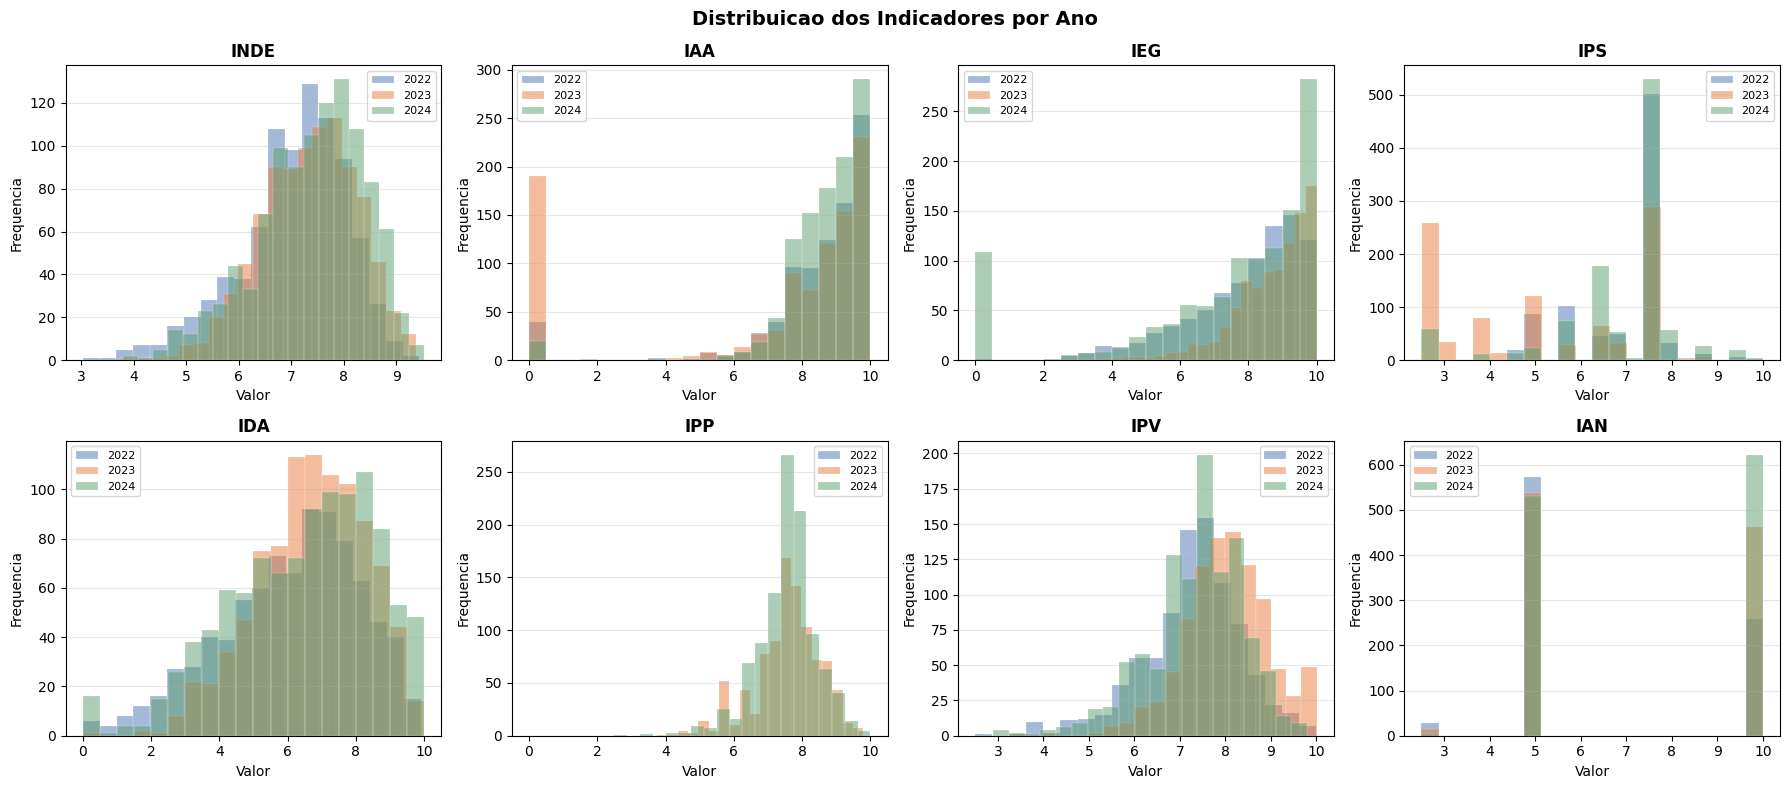

In [17]:
n_inds = len(inds_disponiveis)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distribuicao dos Indicadores por Ano', fontsize=14, fontweight='bold')

cores_ano = {2022: '#4B72B0', 2023: '#E87B3B', 2024: '#5B9E6E'}

for i, ind in enumerate(inds_disponiveis[:8]):
    ax = axes[i // 4][i % 4]
    for ano in sorted(df_all['ANO'].unique()):
        dados = df_all[df_all['ANO'] == ano][ind].dropna()
        ax.hist(dados, bins=20, alpha=0.5, label=str(ano),
                color=cores_ano.get(ano, 'gray'), edgecolor='white', linewidth=0.3)
    ax.set_title(ind, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequencia')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/distribuicao_indicadores.png', dpi=120, bbox_inches='tight')
plt.show()

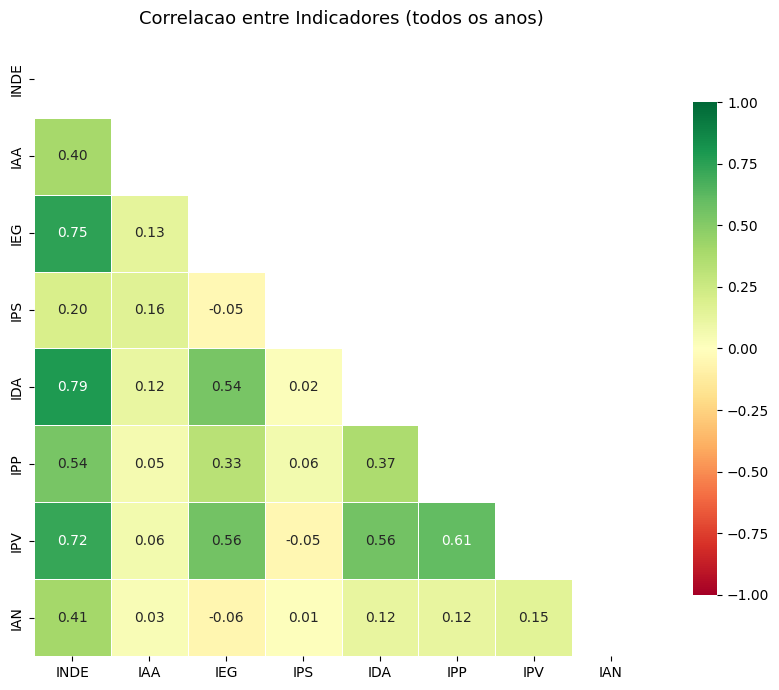

In [18]:
# Matriz de correlacao dos indicadores
if len(inds_disponiveis) >= 2:
    fig, ax = plt.subplots(figsize=(9, 7))
    corr = df_all[inds_disponiveis].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
        vmin=-1, vmax=1, center=0,
        square=True, linewidths=0.5, ax=ax,
        cbar_kws={'shrink': 0.8}
    )
    ax.set_title('Correlacao entre Indicadores (todos os anos)', fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig('../data/correlacao_indicadores.png', dpi=120, bbox_inches='tight')
    plt.show()

## 8. Export dos datasets limpos

In [19]:
os.makedirs(DATA_PATH, exist_ok=True)

# 1. Consolidado completo
path_consolidado = os.path.join(DATA_PATH, 'pede_consolidado.csv')
df_all.to_csv(path_consolidado, index=False, encoding='utf-8-sig')
print(f'Consolidado: {path_consolidado} ({df_all.shape})')

# 2. Por ano
for ano, df in dfs_limpos.items():
    path_ano = os.path.join(DATA_PATH, f'pede_{ano}_limpo.csv')
    df.to_csv(path_ano, index=False, encoding='utf-8-sig')
    print(f'{ano}: {path_ano} ({df.shape[0]} registros)')

# 3. Dataset enxuto para ML
COLUNAS_ML = ['RA', 'ANO', 'Fase'] + inds_disponiveis + ['Defas', 'Atingiu_PV', 'EM_RISCO']
cols_ml = [c for c in COLUNAS_ML if c in df_all.columns]
df_ml = df_all[cols_ml].dropna(subset=[c for c in inds_disponiveis if c in df_all.columns])
path_ml = os.path.join(DATA_PATH, 'pede_ml.csv')
df_ml.to_csv(path_ml, index=False, encoding='utf-8-sig')
print(f'ML: {path_ml} ({df_ml.shape})')

Consolidado: C:\Users\thiag\Desktop\POSTECH 5\passos_magicos\data\pede_consolidado.csv ((3030, 64))
2022: C:\Users\thiag\Desktop\POSTECH 5\passos_magicos\data\pede_2022_limpo.csv (860 registros)
2023: C:\Users\thiag\Desktop\POSTECH 5\passos_magicos\data\pede_2023_limpo.csv (1014 registros)
2024: C:\Users\thiag\Desktop\POSTECH 5\passos_magicos\data\pede_2024_limpo.csv (1156 registros)
ML: C:\Users\thiag\Desktop\POSTECH 5\passos_magicos\data\pede_ml.csv ((1985, 14))


## 9. Resumo final

In [20]:
print('=' * 55)
print('  RESUMO — PASSOS MAGICOS DATATHON')
print('=' * 55)
for ano, df in dfs_limpos.items():
    print(f'  PEDE {ano}: {df.shape[0]} alunos')
print(f'\n  Total consolidado:  {df_all.shape[0]} registros')
print(f'  Alunos unicos (RA): {df_all["RA"].nunique()}')
print(f'  Indicadores:        {inds_disponiveis}')
if 'EM_RISCO' in df_all.columns:
    pct_risco = df_all['EM_RISCO'].mean() * 100
    print(f'\n  Alunos em risco:    {pct_risco:.1f}%')
print('\n  Arquivos gerados:')
print('  -> data/pede_consolidado.csv')
print('  -> data/pede_XXXX_limpo.csv')
print('  -> data/pede_ml.csv')
print('\n  Proximo passo: 02_eda.ipynb')

  RESUMO — PASSOS MAGICOS DATATHON
  PEDE 2022: 860 alunos
  PEDE 2023: 1014 alunos
  PEDE 2024: 1156 alunos

  Total consolidado:  3030 registros
  Alunos unicos (RA): 1661
  Indicadores:        ['INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN']

  Alunos em risco:    16.5%

  Arquivos gerados:
  -> data/pede_consolidado.csv
  -> data/pede_XXXX_limpo.csv
  -> data/pede_ml.csv

  Proximo passo: 02_eda.ipynb
